In [17]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate, GroupKFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import AdaBoostRegressor

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("final_data.csv")

target_col = "Learning.Adjusted.Years.of.School"
groups = df["Country.x"]
X = df.drop(columns=[target_col, "Country.x", "key", "Currency"], errors="ignore")
y = df[target_col]

feature_cols = X.select_dtypes(include=["number", "integer"]).columns.drop(["Year"], errors="ignore")

from sklearn.model_selection import GridSearchCV

param_grids = {
    "RandomForest": {
        "regressor__n_estimators": [10, 15, 20],
        "regressor__max_depth": [None, 5, 10]
    },
    "KNN": {
        "regressor__n_neighbors": [3, 5, 7]
    },
    "SVR": {
        "regressor__C": [0.1, 1, 10],
        "regressor__kernel": ["linear", "rbf"]
    },
    "BayesianRidge": {
        "regressor__alpha_1": [1e-6, 1e-3],
        "regressor__alpha_2": [1e-6, 1e-3]
    }
}

preprocessor = ColumnTransformer(transformers=[
    ("impute_and_scale", Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler())
    ]), feature_cols)
], remainder="passthrough")

scoring = {
    "MAE": make_scorer(mean_absolute_error),
    "MSE": make_scorer(mean_squared_error),
    "R2": make_scorer(r2_score)
}

gkf = GroupKFold(n_splits=5)

models = {
    "RandomForest": RandomForestRegressor(random_state=42),
    "LinearRegression": LinearRegression(),
    "BayesianRidge": BayesianRidge(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Voting": VotingRegressor([
        ("lr", LinearRegression()),
        ("rf", RandomForestRegressor(random_state=42)),
        ("knn", KNeighborsRegressor()),
        ("svr", SVR()),
        ("br", BayesianRidge()),
        ("ada", AdaBoostRegressor(random_state=42))
    ]),
    "Stacking": StackingRegressor(
        estimators=[
            ("lr", LinearRegression()),
            ("rf", RandomForestRegressor(random_state=42)),
            ("knn", KNeighborsRegressor()),
            ("br", BayesianRidge())
        ],
        final_estimator=SVR()
    )
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("regressor", model)
    ])

    if name in param_grids:
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            cv=gkf.split(X, y, groups=groups),
            scoring="neg_mean_absolute_error",
            n_jobs=-1
        )
        grid.fit(X, y)
        best_model = grid.best_estimator_
    else:
        best_model = pipeline
        best_model.fit(X, y)

    cv = cross_validate(
        best_model, X, y,
        cv=gkf.split(X, y, groups=groups),
        scoring=scoring
    )

    results.append({
        "Model": name,
        "MAE": np.mean(cv["test_MAE"]),
        "MSE": np.mean(cv["test_MSE"]),
        "R2": np.mean(cv["test_R2"])
    })

results_df = pd.DataFrame(results)
results_df["MAE_rank"] = results_df["MAE"].rank()
results_df["MSE_rank"] = results_df["MSE"].rank()
results_df["R2_rank"] = results_df["R2"].rank(ascending=False)

results_df["Avg_Rank"] = results_df[["MAE_rank", "MSE_rank", "R2_rank"]].mean(axis=1)
results_df = results_df.sort_values(by="Avg_Rank")

print(results_df[["Model", "MAE", "MSE", "R2", "Avg_Rank"]])

              Model       MAE       MSE        R2  Avg_Rank
7          Stacking  0.887160  1.341273  0.801623  1.000000
6            Voting  0.941747  1.463237  0.786088  2.333333
4               SVR  0.950658  1.474368  0.789422  2.666667
1  LinearRegression  0.951152  1.631013  0.773909  4.666667
2     BayesianRidge  0.964396  1.611384  0.773871  5.000000
5          AdaBoost  0.960420  1.613615  0.760615  5.333333
0      RandomForest  0.966285  1.711083  0.746479  7.000000
3               KNN  1.095097  2.118554  0.684663  8.000000


In [19]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 3
top_models = results_df.head(top_n)["Model"].tolist()

all_importances = []

for model_name in top_models:
    print(f"Computing permutation importance for: {model_name}")

    model = models[model_name]

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("regressor", model)
    ])
    pipeline.fit(X, y)

    numeric_feature_names = preprocessor.named_transformers_["impute_and_scale"] \
        .named_steps["imputer"].get_feature_names_out(feature_cols)
    passthrough_features = [col for col in X.columns if col not in feature_cols]
    all_feature_names = list(numeric_feature_names) + passthrough_features

    perm_result = permutation_importance(
        pipeline, X, y,
        n_repeats=10, random_state=42,
        scoring="neg_mean_squared_error"
    )

    model_importance = pd.DataFrame({
        "Feature": all_feature_names,
        "Importance": perm_result.importances_mean
    })

    model_importance["Model"] = model_name
    all_importances.append(model_importance)

Computing permutation importance for: Stacking
Computing permutation importance for: Voting
Computing permutation importance for: SVR


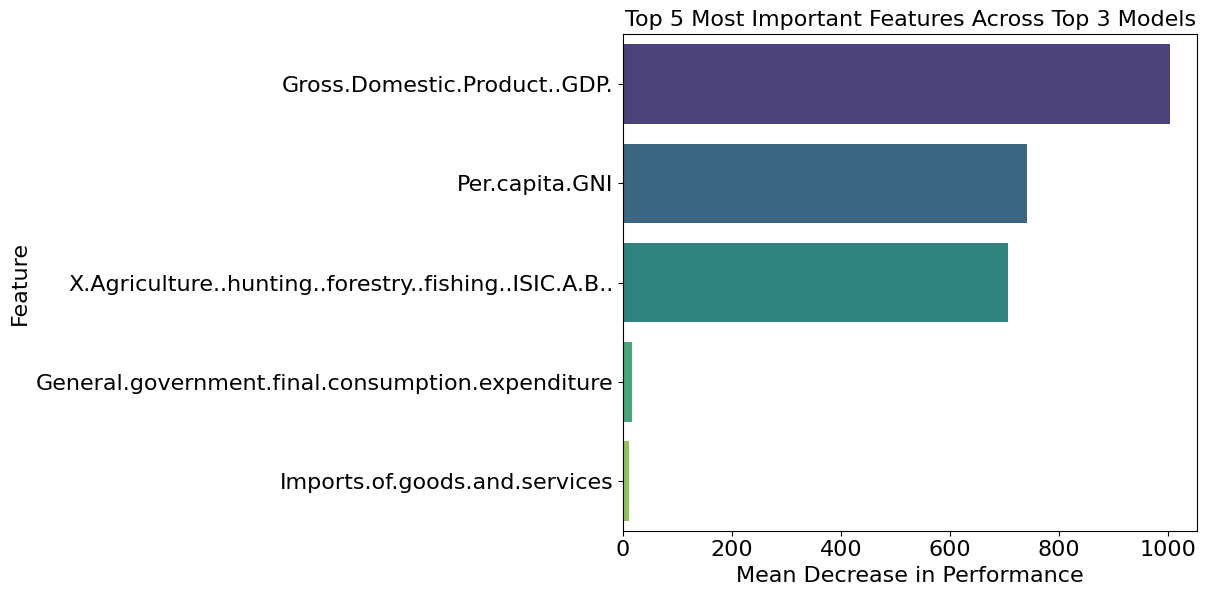

In [23]:
importances_df = pd.concat(all_importances)
avg_importance = importances_df.groupby("Feature")["Importance"].mean().reset_index()
top_features = avg_importance.sort_values(by="Importance", ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y="Feature", palette="viridis")
plt.title("Top 5 Most Important Features Across Top 3 Models", fontsize=16)
plt.xlabel("Mean Decrease in Performance", fontsize=16)
plt.ylabel("Feature", fontsize=16)
plt.tight_layout()
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()